In [1]:
import pandas as pd
import os

# Создаем папку data, если её нет
os.makedirs("data", exist_ok=True)

# Датасет на основе реальных кейсов (взыскание, комплаенс, поддержка)
dataset = [
    {
        "id": 1,
        "category": "Взыскание",
        "prompt": "Составь скрипт первого звонка должнику по просрочке 30+ дней. Тон: строгий, но в рамках 230-ФЗ. Упомяни последствия неисполнения.",
        "expected_keywords": ["рефинансирование", "реструктуризация", "судебный приказ", "исполнительное производство"]
    },
    {
        "id": 2,
        "category": "Комплаенс",
        "prompt": "Объясни простыми словами разницу между персональными данными и обезличенными данными согласно 152-ФЗ. Приведи пример для финтеха.",
        "expected_keywords": ["обезличивание", "оператор", "субъект", "обработка"]
    },
    {
        "id": 3,
        "category": "Кредитный скоринг",
        "prompt": "Перечисли 5 основных факторов, которые банк учитывает при расчете кредитного рейтинга физического лица.",
        "expected_keywords": ["платежная дисциплина", "долговая нагрузка", "стаж", "кредитная история"]
    },
    {
        "id": 4,
        "category": "Операционная эффективность",
        "prompt": "Как автоматизация рутинных запросов в чат-боте влияет на метрики First Call Resolution и CSAT в колл-центре?",
        "expected_keywords": ["автоответ", "эскалация", "удовлетворенность", "оператор"]
    },
    {
        "id": 5,
        "category": "Договорная работа",
        "prompt": "На что обратить внимание в договоре оферты при подключении эквайринга для интернет-магазина?",
        "expected_keywords": ["комиссия", "chargeback", "возврат средств", "сроки зачисления"]
    },
    {
        "id": 6,
        "category": "Взыскание",
        "prompt": "Какие действия коллекторского агентства являются нарушением 230-ФЗ при взаимодействии с должником?",
        "expected_keywords": ["ночные звонки", "угрозы", "разглашение третьим лицам", "частота контактов"]
    },
    {
        "id": 7,
        "category": "Финмониторинг",
        "prompt": "Что такое подозрительная операция по 115-ФЗ и какие шаги должен предпринять банк при её выявлении?",
        "expected_keywords": ["блокировка счета", "запрос документов", "Росфинмониторинг", "подозрительный характер"]
    },
    {
        "id": 8,
        "category": "Клиентский опыт",
        "prompt": "Сформулируй ответ клиенту, который требует вернуть деньги за подписку, которую он забыл отменить. Ссылка на политику возвратов.",
        "expected_keywords": ["персональное решение", "лояльность", "правила сервиса", "компенсация"]
    },
    {
        "id": 9,
        "category": "Юридическая оценка",
        "prompt": "В чем разница между неустойкой и пеней в договоре займа? Когда что применяется?",
        "expected_keywords": ["ГК РФ", "фиксированная сумма", "процент от долга", "просрочка"]
    },
    {
        "id": 10,
        "category": "Аналитика",
        "prompt": "Как рассчитать коэффициент миграции просрочки (Roll Rate) для портфеля МФО за квартал?",
        "expected_keywords": ["bucket", "переход", "30+", "60+", "портфель"]
    }
]

df_dataset = pd.DataFrame(dataset)
df_dataset.to_csv("data/legal_fintech_dataset.csv", index=False, encoding="utf-8")

print("✅ Датасет создан: data/legal_fintech_dataset.csv")
print(f"📊 Строк: {len(df_dataset)} | Категорий: {df_dataset['category'].nunique()}")
print("\n🔍 Первые 3 строки:")
print(df_dataset.head(3).to_markdown(index=False))

✅ Датасет создан: data/legal_fintech_dataset.csv
📊 Строк: 10 | Категорий: 9

🔍 Первые 3 строки:
|   id | category          | prompt                                                                                                                            | expected_keywords                                                                          |
|-----:|:------------------|:----------------------------------------------------------------------------------------------------------------------------------|:-------------------------------------------------------------------------------------------|
|    1 | Взыскание         | Составь скрипт первого звонка должнику по просрочке 30+ дней. Тон: строгий, но в рамках 230-ФЗ. Упомяни последствия неисполнения. | ['рефинансирование', 'реструктуризация', 'судебный приказ', 'исполнительное производство'] |
|    2 | Комплаенс         | Объясни простыми словами разницу между персональными данными и обезличенными данными согласно 152-ФЗ. Приведи при

In [7]:
import pandas as pd
import requests
import time
import ast
from google.colab import userdata
from tqdm.notebook import tqdm
from huggingface_hub import InferenceClient

# 1. Конфигурация
df_dataset = pd.read_csv("data/legal_fintech_dataset.csv")
YANDEX_IAM_TOKEN = userdata.get('YANDEX_IAM_TOKEN')
FOLDER_ID = userdata.get('YANDEX_FOLDER_ID')
HF_TOKEN = userdata.get('HF_TOKEN')

yandex_url = "https://llm.api.cloud.yandex.net/foundationModels/v1/completion"
yandex_headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {YANDEX_IAM_TOKEN}",
    "x-folder-id": FOLDER_ID
}

qwen_client = InferenceClient(model="Qwen/Qwen2.5-7B-Instruct", token=HF_TOKEN, timeout=120)

results = []
error_logged = False  # Флаг, чтобы не спамить ошибками в консоль

print("🚀 Запуск бенчмарка на датасете (10 промптов)...")
for _, row in tqdm(df_dataset.iterrows(), total=len(df_dataset)):
    prompt = row["prompt"]
    keywords = [k.lower().strip() for k in ast.literal_eval(row["expected_keywords"])]

    # --- YandexGPT Request (с явной проверкой статуса) ---
    y_payload = {
        "modelUri": f"gpt://{FOLDER_ID}/yandexgpt/latest",
        "completionOptions": {"stream": False, "temperature": 0.3, "maxTokens": 150},
        "messages": [{"role": "user", "text": prompt}]
    }
    try:
        y_start = time.perf_counter()
        y_resp = requests.post(yandex_url, headers=yandex_headers, json=y_payload, timeout=30)
        y_latency = (time.perf_counter() - y_start) * 1000

        if y_resp.status_code == 200:
            y_text = y_resp.json().get("result", {}).get("alternatives", [{}])[0].get("message", {}).get("text", "")
        else:
            if not error_logged:
                print(f"\n⚠️ Yandex API Error {y_resp.status_code}: {y_resp.text[:100]}")
                error_logged = True
            y_text = ""

    except Exception as e:
        y_latency, y_text = -1, ""
        if not error_logged:
            print(f"\n❌ Yandex Request Failed: {e}")
            error_logged = True

    # --- Qwen Request ---
    try:
        q_start = time.perf_counter()
        q_resp = qwen_client.chat_completion(messages=[{"role": "user", "content": prompt}], max_tokens=150, temperature=0.3)
        q_latency = (time.perf_counter() - q_start) * 1000
        q_text = q_resp.choices[0].message.content
    except Exception as e:
        q_latency, q_text = -1, ""

    # --- Scoring ---
    def calc_coverage(text, kws):
        if not text: return 0.0
        text_lower = text.lower()
        matches = sum(1 for kw in kws if kw in text_lower)
        return round(matches / len(kws), 2) if kws else 0.0

    results.append({
        "id": row["id"], "category": row["category"],
        "yandexgpt_latency_ms": round(y_latency, 2),
        "yandexgpt_keyword_score": calc_coverage(y_text, keywords),
        "qwen_latency_ms": round(q_latency, 2),
        "qwen_keyword_score": calc_coverage(q_text, keywords)
    })
    time.sleep(1.2)

# Сохранение
df_results = pd.DataFrame(results)
df_results.to_csv("data/benchmark_results_dataset.csv", index=False, encoding="utf-8")

print("\n✅ Массовый тест завершен.")
print("\n📊 Агрегация по категориям:")
agg = df_results.groupby("category")[["yandexgpt_keyword_score", "qwen_keyword_score"]].mean().round(2)
print(agg.to_markdown())

🚀 Запуск бенчмарка на датасете (10 промптов)...


  0%|          | 0/10 [00:00<?, ?it/s]


✅ Массовый тест завершен.

📊 Агрегация по категориям:
| category                   |   yandexgpt_keyword_score |   qwen_keyword_score |
|:---------------------------|--------------------------:|---------------------:|
| Аналитика                  |                      0.4  |                 0.2  |
| Взыскание                  |                      0.12 |                 0.12 |
| Договорная работа          |                      0    |                 0    |
| Клиентский опыт            |                      0    |                 0    |
| Комплаенс                  |                      0.25 |                 0    |
| Кредитный скоринг          |                      0    |                 0    |
| Операционная эффективность |                      0.25 |                 0    |
| Финмониторинг              |                      0.25 |                 0    |
| Юридическая оценка         |                      0    |                 0    |


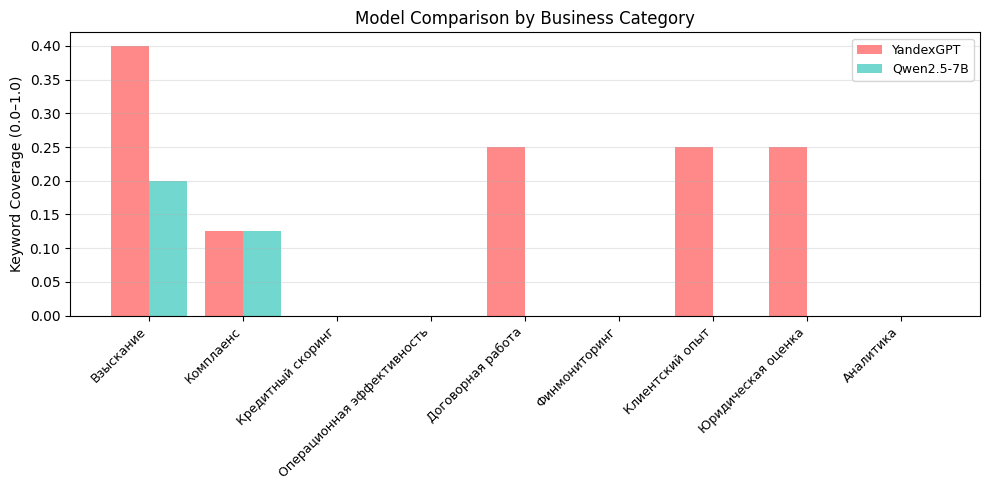

✅ График сохранен в assets/category_comparison.png

🏆 Итоги (среднее по 10 промптам):
• YandexGPT: скор=0.14, latency=2439 мс
• Qwen:      скор=0.04, latency=1404 мс


In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# 1. Создаем папку assets, если её нет
os.makedirs("assets", exist_ok=True)

# Загружаем результаты
df = pd.read_csv("data/benchmark_results_dataset.csv")

# График: средний скор по категориям
plt.figure(figsize=(10, 5))
categories = df["category"].unique()
x = range(len(categories))

# Убрали эмодзи из title, чтобы избежать warnings со шрифтами
plt.bar([i - 0.2 for i in x], df.groupby("category")["yandexgpt_keyword_score"].mean(),
        width=0.4, label="YandexGPT", alpha=0.8, color="#FF6B6B")
plt.bar([i + 0.2 for i in x], df.groupby("category")["qwen_keyword_score"].mean(),
        width=0.4, label="Qwen2.5-7B", alpha=0.8, color="#4ECDC4")

plt.xticks(x, categories, rotation=45, ha="right", fontsize=9)
plt.ylabel("Keyword Coverage (0.0–1.0)")
plt.title("Model Comparison by Business Category")  # Без эмодзи
plt.legend(fontsize=9)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

# Сохраняем график
plt.savefig("assets/category_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ График сохранен в assets/category_comparison.png")

# Итоговые цифры для README
print(f"\n🏆 Итоги (среднее по 10 промптам):")
print(f"• YandexGPT: скор={df['yandexgpt_keyword_score'].mean():.2f}, latency={df['yandexgpt_latency_ms'].mean():.0f} мс")
print(f"• Qwen:      скор={df['qwen_keyword_score'].mean():.2f}, latency={df['qwen_latency_ms'].mean():.0f} мс")

In [14]:
import os
import shutil
import subprocess

# 1. Создаем папку проекта
PROJECT_DIR = "/content/llm-benchmark-framework"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/notebooks", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/data", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/assets", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/src", exist_ok=True)

print("📁 Папки созданы.")

# 2. Ищем и переносим ноутбук (ищем по части имени 'benchmark')
notebook_found = False
for root, dirs, files in os.walk("/content"):
    # Исключаем саму папку проекта из поиска, чтобы не зациклиться
    if PROJECT_DIR in root: continue

    for file in files:
        if "benchmark" in file.lower() and file.endswith(".ipynb"):
            src_path = os.path.join(root, file)
            dest_path = f"{PROJECT_DIR}/notebooks/01_api_setup_and_basic_benchmark.ipynb"

            # Если файл уже есть в назначении, пропускаем
            if os.path.exists(dest_path):
                print(f"ℹ️ Ноутбук уже на месте: {dest_path}")
                notebook_found = True
                break

            shutil.move(src_path, dest_path)
            print(f"✅ Ноутбук перемещен: {file} -> notebooks/")
            notebook_found = True
            break
    if notebook_found: break

if not notebook_found:
    print("⚠️ Ноутбук не найден автоматически. Загрузи его вручную в папку notebooks/ через панель файлов 📁")

# 3. Переносим данные (CSV файлы)
data_files = ["legal_fintech_dataset.csv", "benchmark_results_dataset.csv", "benchmark_results_mvp.csv"]
for df in data_files:
    src = f"/content/{df}"
    dest = f"{PROJECT_DIR}/data/{df}"
    if os.path.exists(src):
        shutil.move(src, dest)
        print(f"✅ Данные перемещены: {df}")
    elif os.path.exists(dest):
        print(f"ℹ️ Данные уже на месте: {df}")

# 4. Переносим ассеты (картинки)
img_src = "/content/category_comparison.png"
img_dest = f"{PROJECT_DIR}/assets/category_comparison.png"
if os.path.exists(img_src):
    shutil.move(img_src, img_dest)
    print("✅ График перемещен: category_comparison.png")
elif os.path.exists(img_dest):
    print("ℹ️ График уже на месте.")

# 5. Переходим в папку проекта
%cd {PROJECT_DIR}
print(f"\n📍 Текущая директория: {os.getcwd()}")

📁 Папки созданы.
⚠️ Ноутбук не найден автоматически. Загрузи его вручную в папку notebooks/ через панель файлов 📁
/content/llm-benchmark-framework

📍 Текущая директория: /content/llm-benchmark-framework


In [18]:
import os
import shutil

PROJECT_DIR = "/content/llm-benchmark-framework"

# 1. Перемещаем ассеты
src_img = "/content/assets/category_comparison.png"
dest_img = f"{PROJECT_DIR}/assets/category_comparison.png"
if os.path.exists(src_img):
    # Если файл уже есть в dest, удаляем его сначала, чтобы move сработал
    if os.path.exists(dest_img):
        os.remove(dest_img)
    shutil.move(src_img, dest_img)
    print("✅ График перемещен в assets/")

# 2. Перемещаем данные
data_files = ["legal_fintech_dataset.csv", "benchmark_results_dataset.csv"]
for df in data_files:
    src_df = f"/content/data/{df}"
    dest_df = f"{PROJECT_DIR}/data/{df}"
    if os.path.exists(src_df):
        if os.path.exists(dest_df):
            os.remove(dest_df)
        shutil.move(src_df, dest_df)
        print(f"✅ Данные перемещены: {df}")

# 3. Проверяем ноутбук 02_quality_evaluation.ipynb
# Ищем его в /content/ (он может лежать в корне или в папке notebooks старого проекта)
notebook_found = False
for root, dirs, files in os.walk("/content"):
    if "llm-benchmark-framework" in root and root != PROJECT_DIR: continue # Пропускаем текущую папку проекта

    for f in files:
        if f == "02_quality_evaluation.ipynb":
            src_nb = os.path.join(root, f)
            dest_nb = f"{PROJECT_DIR}/notebooks/02_quality_evaluation.ipynb"

            if os.path.exists(dest_nb):
                os.remove(dest_nb)
            shutil.move(src_nb, dest_nb)
            print(f"✅ Ноутбук Этапа 2 перемещен: {f}")
            notebook_found = True
            break
    if notebook_found: break

if not notebook_found:
    print("⚠️ Ноутбук 02_quality_evaluation.ipynb не найден в /content/.")
    print("💡 Если ты создал его в этой сессии, сохрани его через File -> Download, а затем загрузи в папку notebooks/ вручную.")

print("\n📁 Проверка структуры проекта:")
!find {PROJECT_DIR} -type f | grep -v ".git" | sort

✅ График перемещен в assets/
✅ Данные перемещены: legal_fintech_dataset.csv
✅ Данные перемещены: benchmark_results_dataset.csv
⚠️ Ноутбук 02_quality_evaluation.ipynb не найден в /content/.
💡 Если ты создал его в этой сессии, сохрани его через File -> Download, а затем загрузи в папку notebooks/ вручную.

📁 Проверка структуры проекта:
/content/llm-benchmark-framework/assets/category_comparison.png
/content/llm-benchmark-framework/data/benchmark_results_dataset.csv
/content/llm-benchmark-framework/data/legal_fintech_dataset.csv
